In [ ]:
import json
import pandas as pd
import numpy as np
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# ─── 1) Picklable MutualInfo selector ────────────────────────────────────────
class MutualInfoSelector(SelectKBest):
    def __init__(self, n_discrete, k=10):
        self.n_discrete = n_discrete
        super().__init__(score_func=self._mi, k=k)

    def _mi(self, X, y):
        mask = [True] * self.n_discrete + [False] * (X.shape[1] - self.n_discrete)
        return mutual_info_classif(X, y, discrete_features=mask)

# ─── 2) Helpers ─────────────────────────────────────────────────────────────
def load_config(path="config.json"):
    with open(path) as f:
        return json.load(f)

def load_data(train_path, test_path, target_col):
    df_train = pd.read_csv(train_path)
    df_test  = pd.read_csv(test_path)
    if target_col in df_test.columns:
        y_test = df_test[target_col].astype(str)
        df_test = df_test.drop(columns=[target_col])
    else:
        y_test = None
    return df_train, df_test, y_test

def build_pipeline(cat_cols, num_cols, k=10):
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", StandardScaler(), num_cols),
    ], remainder="drop")
    selector = MutualInfoSelector(n_discrete=len(cat_cols), k=k)
    clf      = XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0)
    return Pipeline([("prep", pre), ("select", selector), ("clf", clf)])

def align_test(df, train_cols, cat_cols):
    for c in train_cols:
        if c not in df:
            df[c] = "missing" if c in cat_cols else 0
    extras = [c for c in df.columns if c not in train_cols]
    return df.drop(columns=extras)[train_cols]

def assign_deciles(scores, n=10):
    """
    Rank‐based, equal-sized deciles: D1=lowest, Dn=highest risk.
    """
    ranks = scores.rank(method="first")
    total = len(scores)
    bucket = np.ceil(ranks / total * n).astype(int).clip(1, n)
    return [f"D{b}" for b in bucket]

# ─── 3) Main ────────────────────────────────────────────────────────────────
def main():
    # load config & data
    cfg = load_config()
    proxy_feats = cfg["dataset"]["proxy_features"]
    target_col  = cfg["dataset"]["target_variable"]

    df_tr, df_te, y_te_true = load_data(
        "cleaned_data.csv", "test_data.csv", target_col
    )
    ids = df_te[["Order_ID"]].reset_index(drop=True)

    # prepare train/val split
    y_full = df_tr[target_col].astype(str)
    y, labels = pd.factorize(y_full)
    X_full = df_tr.drop(columns=proxy_feats + [target_col], errors="ignore")

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_full, y, test_size=0.2, stratify=y, random_state=42
    )

    # identify column types
    cat_cols   = X_tr.select_dtypes(include=["object","category"]).columns.tolist()
    num_cols   = X_tr.select_dtypes(include=["number"]).columns.tolist()
    train_cols = cat_cols + num_cols

    # align test set
    X_test = align_test(df_te.copy(), train_cols, cat_cols)

    # build & calibrate pipeline
    base_pipe = build_pipeline(cat_cols, num_cols, k=10)
    calib     = CalibratedClassifierCV(base_pipe, cv=5, method="sigmoid")
    calib.fit(X_tr, y_tr)

    # validation AUC
    val_p = calib.predict_proba(X_val)[:,1]
    print(f"Validation AUC-ROC: {roc_auc_score(y_val, val_p):.4f}")

    # **use threshold = 0.09** as per your latest run
    THRESH = 0.09

    # score test set
    p_test    = calib.predict_proba(X_test)[:,1]
    pred_test = (p_test >= THRESH).astype(int)

    # assemble results
    results = pd.DataFrame({
        "customer_id":            ids["Order_ID"],
        "propensity_score_churn": p_test,
        "predicted_label":        [labels[i] for i in pred_test]
    })

    # assign equal-sized deciles
    results["decile"] = assign_deciles(results["propensity_score_churn"], n=10)

    # summary (D10 highest first)
    order = [f"D{i}" for i in range(10,0,-1)]
    summary = (
        results
        .groupby("decile", sort=False)["propensity_score_churn"]
        .agg(count="size", mean="mean")
        .reindex(order)
    )
    print("\nDecile Summary:")
    print(summary)

    # save to CSV & pickle
    results.to_csv("churn_propensity.csv", index=False)
    print("\n➡️ Saved scores to churn_propensity.csv")

    joblib.dump(calib, "churn_propensity_calibrated_pipeline.joblib")
    print("➡️ Saved pipeline to churn_propensity_calibrated_pipeline.joblib")

    # final test evaluation
    if y_te_true is not None:
        true_te = pd.factorize(y_te_true.astype(str))[0]
        print(f"\nTest Report @ thresh={THRESH}:")
        print(classification_report(true_te, pred_test, target_names=labels))
        print("Confusion Matrix:")
        print(confusion_matrix(true_te, pred_test))

if __name__ == "__main__":
    main()


Validation AUC-ROC: 0.8677

Decile Summary:
        count      mean
decile                 
D10       300  0.590081
D9        300  0.166020
D8        300  0.110566
D7        300  0.088978
D6        300  0.086665
D5        300  0.086650
D4        300  0.086645
D3        300  0.086644
D2        300  0.086644
D1        300  0.086643

➡️ Saved scores to churn_propensity.csv
➡️ Saved pipeline to churn_propensity_calibrated_pipeline.joblib

Test Report @ thresh=0.5:
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99      2695
        High       1.00      0.80      0.89       305

    accuracy                           0.98      3000
   macro avg       0.99      0.90      0.94      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
[[2695    0]
 [  61  244]]


In [ ]:
import json
import pandas as pd
import numpy as np
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

class MutualInfoSelector(SelectKBest):
    def __init__(self, n_discrete, k=10):
        self.n_discrete = n_discrete
        super().__init__(score_func=self._mi, k=k)
    def _mi(self, X, y):
        mask = [True]*self.n_discrete + [False]*(X.shape[1]-self.n_discrete)
        return mutual_info_classif(X, y, discrete_features=mask)

def load_config(path="config.json"):
    with open(path) as f:
        return json.load(f)

def load_data(train_path, test_path, target_col):
    df_tr = pd.read_csv(train_path)
    df_te = pd.read_csv(test_path)
    if target_col in df_te.columns:
        y_te = df_te[target_col].astype(str)
        df_te = df_te.drop(columns=[target_col])
    else:
        y_te = None
    return df_tr, df_te, y_te

def build_pipeline(cat_cols, num_cols, k=10):
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", StandardScaler(), num_cols),
    ], remainder="drop")
    sel = MutualInfoSelector(n_discrete=len(cat_cols), k=k)
    clf = XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0)
    return Pipeline([("prep", pre), ("select", sel), ("clf", clf)])

def align_test(df, train_cols, cat_cols):
    for c in train_cols:
        if c not in df:
            df[c] = "missing" if c in cat_cols else 0
    extras = [c for c in df.columns if c not in train_cols]
    return df.drop(columns=extras)[train_cols]

def main():
    cfg = load_config()
    proxy_feats = cfg["dataset"]["proxy_features"]
    target_col  = cfg["dataset"]["target_variable"]

    # 1) load data
    df_tr, df_te, y_te_true = load_data("cleaned_data.csv", "test_data.csv", target_col)

    # 2) detect & parse date
    date_cols = [c for c in df_te.columns if "date" in c.lower()]
    if not date_cols:
        raise KeyError("No 'date' column found in test_data.csv")
    date_col = date_cols[0]
    df_te[date_col] = pd.to_datetime(df_te[date_col])

    # 3) keep IDs + dates
    ids_dates = df_te[["Order_ID", date_col]].rename(
        columns={"Order_ID":"customer_id", date_col:"Order_Date"}
    )

    # 4) train/val setup
    y_full = df_tr[target_col].astype(str)
    y, labels = pd.factorize(y_full)
    X_full = df_tr.drop(columns=proxy_feats + [target_col], errors="ignore")
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_full, y, test_size=0.2, stratify=y, random_state=42
    )

    # 5) feature typing
    cat_cols   = X_tr.select_dtypes(include=["object","category"]).columns.tolist()
    num_cols   = X_tr.select_dtypes(include=["number"]).columns.tolist()
    train_cols = cat_cols + num_cols

    # 6) prepare test features
    X_test = align_test(df_te.copy(), train_cols, cat_cols)

    # 7) build & calibrate model
    pipe = build_pipeline(cat_cols, num_cols, k=10)
    calib = CalibratedClassifierCV(pipe, cv=5, method="sigmoid")
    calib.fit(X_tr, y_tr)

    # 8) validation performance
    val_p = calib.predict_proba(X_val)[:,1]
    print(f"Validation AUC-ROC: {roc_auc_score(y_val, val_p):.4f}")

    # 9) score test set
    THRESH = 0.1
    p_test = calib.predict_proba(X_test)[:,1]

    # 10) assemble base results
    results = ids_dates.copy()
    results["propensity_score"] = p_test

    # 11) default churn flag (full period)
    results["churn"] = (results["propensity_score"] >= THRESH).astype(int)

    # 12) horizon flags relative to today
    today = pd.Timestamp.today().normalize()
    for m in [3, 6, 9]:
        cutoff = today - pd.DateOffset(months=m)
        col = f"churn_{m}m"
        results[col] = (
            (results["Order_Date"] >= cutoff) &
            (results["propensity_score"] >= THRESH)
        ).astype(int)

    # 13) save everything in one CSV
    results.to_csv("churn_horizon_flags.csv", index=False)
    print(" Saved churn_horizon_flags.csv with columns:", list(results.columns))

    # 14) optional: overall test metrics
    if y_te_true is not None:
        pred_full = results["churn"].values
        true_te = pd.factorize(y_te_true.astype(str))[0]
        print("\nTest Report @ thresh=0.09 (full period):")
        print(classification_report(true_te, pred_full, target_names=labels))
        print("Confusion Matrix:")
        print(confusion_matrix(true_te, pred_full))

    # 15) persist model
    joblib.dump(calib, "churn_model.joblib")

if __name__ == "__main__":
    main()


Validation AUC-ROC: 0.8543
 Saved churn_horizon_flags.csv with columns: ['customer_id', 'Order_Date', 'propensity_score', 'churn', 'churn_3m', 'churn_6m', 'churn_9m']

Test Report @ thresh=0.09 (full period):
              precision    recall  f1-score   support

         Low       0.99      0.78      0.87      2695
        High       0.32      0.91      0.47       305

    accuracy                           0.79      3000
   macro avg       0.65      0.84      0.67      3000
weighted avg       0.92      0.79      0.83      3000

Confusion Matrix:
[[2106  589]
 [  28  277]]


In [ ]:
df = pd.read_csv("churn_horizon_flags.csv")
df

,customer_id,Order_Date,propensity_score,churn,churn_3m,churn_6m,churn_9m
0,ORD10000,2021-04-01,0.085098,0,0,0,0
1,ORD10000,2022-05-01,0.085112,0,0,0,0
2,ORD10000,2022-02-01,0.085113,0,0,0,0
3,ORD10000,2022-02-01,0.085095,0,0,0,0
4,ORD10000,2022-01-01,0.085089,0,0,0,0
...,...,...,...,...,...,...,...
2995,ORD10995,2024-12-28,0.251250,1,0,1,1
2996,ORD10996,2024-12-20,0.155481,1,0,1,1
2997,ORD10997,2024-10-02,0.635422,1,0,0,1
2998,ORD10998,2025-01-23,0.265037,1,0,1,1


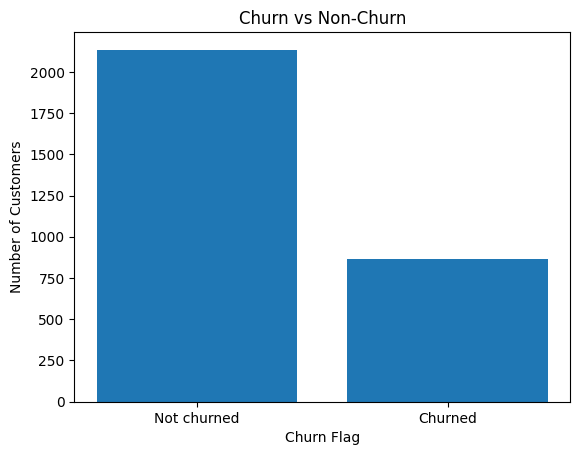

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'churn_horizon_flags.csv'
if not os.path.exists(file_path):
    print(f"⚠️ File '{file_path}' not found. Please run the churn script to generate it first.")
else:
    # Load the results
    df = pd.read_csv(file_path)

    # Compute counts for overall churn flag
    counts = df['churn'].value_counts().sort_index()
    labels = ['Not churned', 'Churned']
    values = [counts.get(0, 0), counts.get(1, 0)]

    # Plot
    plt.figure()
    plt.bar(labels, values)
    plt.title('Churn vs Non-Churn')
    plt.xlabel('Churn Flag')
    plt.ylabel('Number of Customers')
    plt.show()


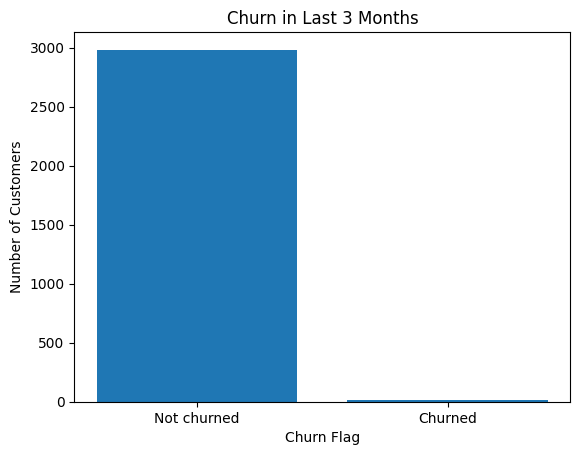

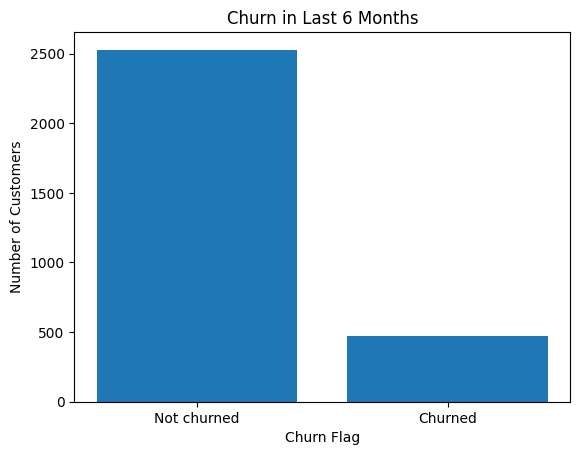

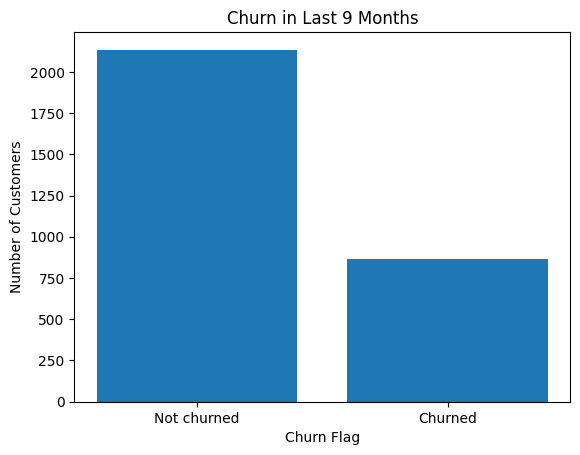

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'churn_horizon_flags.csv'
if not os.path.exists(file_path):
    print(f"⚠️ File '{file_path}' not found. Please run the churn script to generate it first.")
else:
    df = pd.read_csv(file_path)
    horizons = [
        ('churn_3m', 'Last 3 Months'),
        ('churn_6m', 'Last 6 Months'),
        ('churn_9m', 'Last 9 Months')
    ]

    for col, label in horizons:
        counts = df[col].value_counts().sort_index()
        labels_flag = ['Not churned', 'Churned']
        values = [counts.get(0, 0), counts.get(1, 0)]

        plt.figure()
        plt.bar(labels_flag, values)
        plt.title(f'Churn in {label}')
        plt.xlabel('Churn Flag')
        plt.ylabel('Number of Customers')
        plt.show()


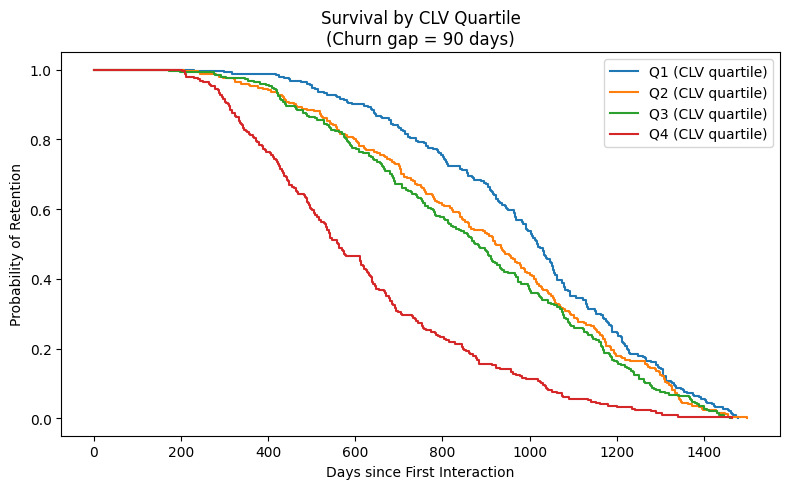


Total customers: 1000, churn events: 1000

=== Cox Proportional Hazards Model ===

                     coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                        
clv_30m          0.819498   2.269361  0.042225        0.736739   
age              0.011904   1.011975  0.030783       -0.048430   
total_purchases -0.279462   0.756190  0.035981       -0.349983   

                 coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                   
clv_30m                0.902257             2.089112             2.465161   
age                    0.072237             0.952724             1.074910   
total_purchases       -0.208941             0.704700             0.811443   

                 cmp to          z             p    -log2(p)  
covariate                                                     
clv_30m             0.0  19.408004  6.604366e-84  276.318540  
age       

In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from lifelines import KaplanMeierFitter, CoxPHFitter
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ─── USER CONFIG ─────────────────────────────────────────────────────────────
CHURN_GAP_DAYS = 90    # no purchase for this many days ⇒ churn event
TODAY           = pd.to_datetime("2025-05-23")  # for censoring “active” customers
MIN_EVENTS      = 10    # recommend ≥10 events to trust Cox PH
# ──────────────────────────────────────────────────────────────────────────────

def extract_purchase_count(s):
    """Parse 'Item (7 times)' → 7.0, else 0.0."""
    return s.str.extract(r'\((\d+)\s+times\)')[0].astype(float).fillna(0.0)

def main():
    # 1) Load customer data
    df = pd.read_csv(
        "formatting_data.csv",
        parse_dates=["First Interaction Date","Last Purchase Date"]
    )

    # 2) Define churn event by purchase gap
    df["days_since_last"] = (TODAY - df["Last Purchase Date"]).dt.days
    df["event_observed"]  = (df["days_since_last"] > CHURN_GAP_DAYS).astype(int)

    # 3) Set duration: first→last purchase if churned, else first→today
    df["duration"] = np.where(
        df["event_observed"] == 1,
        (df["Last Purchase Date"] - df["First Interaction Date"]).dt.days,
        (TODAY - df["First Interaction Date"]).dt.days
    )
    df = df[df["duration"] > 0].copy()

    # 4) Compute per‐record purchase_count & revenue
    df["purchase_count"] = extract_purchase_count(df["Purchase History"])
    df["revenue"]        = df["Avg Order Value"] * df["purchase_count"]

    # 5) Aggregate one row per customer (Email)
    cust = df.groupby("Email").agg(
        duration        = ("duration",       "first"),
        event_observed  = ("event_observed", "max"),
        total_purchases = ("purchase_count", "sum"),
        total_revenue   = ("revenue",        "sum"),
        age             = ("Age",            "first"),
    ).reset_index()

    # 6) Compute 30-month CLV proxy
    cust["avg_order_value"] = (
        cust["total_revenue"] /
        cust["total_purchases"].replace(0, np.nan)
    ).fillna(0.0)
    cust["monthly_rate"] = cust["total_purchases"] / np.maximum(cust["duration"]/30.0, 1.0)
    cust["clv_30m"]      = cust["monthly_rate"] * 30 * cust["avg_order_value"]

    # 7) Kaplan–Meier by CLV quartile
    cust["clv_q"] = pd.qcut(
        cust["clv_30m"].rank(method="first"),
        4, labels=["Q1","Q2","Q3","Q4"]
    )
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8,5))
    for q in ["Q1","Q2","Q3","Q4"]:
        mask = cust["clv_q"] == q
        kmf.fit(
            durations      = cust.loc[mask,"duration"],
            event_observed = cust.loc[mask,"event_observed"],
            label          = f"{q} (CLV quartile)"
        )
        kmf.plot_survival_function(ci_show=False)
    plt.title(f"Survival by CLV Quartile\n(Churn gap = {CHURN_GAP_DAYS} days)")
    plt.xlabel("Days since First Interaction")
    plt.ylabel("Probability of Retention")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Cox Proportional Hazards
    n_events = int(cust["event_observed"].sum())
    print(f"\nTotal customers: {len(cust)}, churn events: {n_events}")
    if n_events < MIN_EVENTS:
        print(f"⚠️ Only {n_events} events (<{MIN_EVENTS}); interpret Cox PH with caution.\n")

    df_cox = cust[["duration","event_observed","clv_30m","age","total_purchases"]].copy()
    for col in ["clv_30m","age","total_purchases"]:
        df_cox[col] = (df_cox[col] - df_cox[col].mean()) / df_cox[col].std()

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(df_cox, duration_col="duration", event_col="event_observed")
    print("\n=== Cox Proportional Hazards Model ===\n")
    print(cph.summary)

if __name__ == "__main__":
    main()
